# Upsell Opportunity Detection - Exploratory Data Analysis

## Purpose
This notebook performs comprehensive EDA to identify upsell/cross-sell opportunities based on:
- License utilization patterns
- Account growth trajectory
- Industry benchmarks
- Contract duration and maturity
- Customer health and sentiment scores
- Revenue potential

## Key Metrics Analyzed
- **License Utilization** - Current usage vs capacity
- **ARR Growth Potential** - Revenue expansion opportunities
- **Account Health** - Readiness for upsell conversations
- **Contract Duration** - Maturity indicators
- **Industry Benchmarks** - Comparative analysis

In [4]:
# Install required packages
!uv add pandas numpy matplotlib seaborn openpyxl

Resolved 54 packages in 1ms
Audited 47 packages in 2ms


In [5]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load and Explore Data

In [6]:
# Load the dataset
# Try multiple possible paths
possible_paths = [
    Path("../../customer_data_25000.xlsx"),
    Path("../customer_data_25000.xlsx"),
    Path("customer_data_25000.xlsx"),
    Path("D:/Internship/Renewal-Upsell-Advisor/Research/customer_data_25000.xlsx")
]

data_path = None
for path in possible_paths:
    if path.exists():
        data_path = path
        break

if data_path is None:
    raise FileNotFoundError("Could not find customer_data_25000.xlsx. Please check the file path.")

df = pd.read_excel(data_path, sheet_name="Accounts")

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumn Names:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

print(f"\nFirst few rows:")
df.head()

Dataset loaded successfully!
Shape: 24,874 rows × 27 columns

Column Names:
   1. name
   2. domain
   3. industry
   4. company_size
   5. arr
   6. mrr
   7. contract_start_date
   8. contract_end_date
   9. renewal_date
  10. last_contact_date
  11. status
  12. renewal_stage
  13. health_score
  14. risk_score
  15. relationship_score
  16. churn_probability
  17. sentiment_score
  18. sentiment_category
  19. licenses_total
  20. licenses_used
  21. utilization_percentage
  22. csm_name
  23. csm_email
  24. primary_contact_name
  25. primary_contact_email
  26. primary_contact_phone
  27. salesforce_id

First few rows:


,name,domain,industry,company_size,arr,mrr,contract_start_date,contract_end_date,renewal_date,last_contact_date,...,sentiment_category,licenses_total,licenses_used,utilization_percentage,csm_name,csm_email,primary_contact_name,primary_contact_email,primary_contact_phone,salesforce_id
0,Cole LLC,colellc.com,Technology,Small,156049,13004.08,2025-06-05,2026-06-05,2026-06-05,2026-02-13 16:43:27,...,neutral,20,15,79,Sarah Chen,sarah.chen@company.com,Danielle Johnson,john21@example.net,001-581-896-0013x3890,NaN
1,"Stevens, Martinez and Nielsen",stevensmartinezandnielsen.com,Healthcare,Medium,517493,43124.42,2025-05-19,2026-05-19,2026-05-19,2026-02-04 16:43:27,...,positive,30,23,79,Maria Lopez,maria.lopez@company.com,Lisa Smith,helenpeterson@example.org,651.216.1559,NaN
2,Clark-Adams,clark-adams.com,Analytics,Large,64898,5408.17,2025-04-28,2026-04-28,2026-04-28,2026-02-12 16:43:27,...,negative,20,14,73,Emily Rodriguez,emily.rodriguez@company.com,Christian Carter,barbara10@example.net,441.731.6475,SF-748564
3,"Porter, Wilkerson and Day",porterwilkersonandday.com,Healthcare,Medium,43003,3583.58,2025-05-01,2026-05-01,2026-05-01,2026-02-06 16:43:27,...,neutral,20,14,73,David Kim,david.kim@company.com,Sharon Wong,amandasanchez@example.com,(748)535-0305x6413,SF-319684
4,Carlson-Mcdonald,carlson-mcdonald.com,Enterprise,Medium,100005,8333.75,2025-06-09,2026-06-09,2026-06-09,2026-01-19 16:43:27,...,very_positive,50,33,66,Sarah Chen,sarah.chen@company.com,Douglas Taylor,julie69@example.com,(332)887-1012x269,SF-944151


In [7]:
# Basic information about the dataset
print("=" * 80)
print("DATASET INFORMATION")
print("=" * 80)
print(f"\nTotal Records: {len(df):,}")
print(f"Total Columns: {len(df.columns)}")
print(f"\nData Types:")
print(df.dtypes)

print(f"\nMissing Values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage': missing_pct
}).sort_values('Missing Count', ascending=False)
print(missing_df[missing_df['Missing Count'] > 0])

DATASET INFORMATION

Total Records: 24,874
Total Columns: 27

Data Types:
name                          str
domain                        str
industry                      str
company_size                  str
arr                         int64
mrr                       float64
contract_start_date           str
contract_end_date             str
renewal_date                  str
last_contact_date             str
status                        str
renewal_stage                 str
health_score                int64
risk_score                  int64
relationship_score          int64
churn_probability         float64
sentiment_score           float64
sentiment_category            str
licenses_total              int64
licenses_used               int64
utilization_percentage      int64
csm_name                      str
csm_email                     str
primary_contact_name          str
primary_contact_email         str
primary_contact_phone         str
salesforce_id                 str
dtype: o

## 2. Feature Engineering for Upsell Analysis

In [8]:
# Create a working copy
df_upsell = df.copy()

# Convert date columns to datetime
date_columns = ['contract_start_date', 'contract_end_date', 'renewal_date', 'last_contact_date']
for col in date_columns:
    if col in df_upsell.columns:
        df_upsell[col] = pd.to_datetime(df_upsell[col], errors='coerce')

# Calculate contract duration (months)
if 'contract_start_date' in df_upsell.columns:
    today = pd.Timestamp.now()
    df_upsell['contract_duration_months'] = (
        (today - df_upsell['contract_start_date']).dt.days / 30.44
    ).round(1)
    # Handle any negative or invalid values
    df_upsell['contract_duration_months'] = df_upsell['contract_duration_months'].fillna(0).clip(lower=0)

# Calculate days until renewal
if 'renewal_date' in df_upsell.columns:
    df_upsell['days_until_renewal'] = (
        df_upsell['renewal_date'] - today
    ).dt.days
    # Handle any negative values (past renewals)
    df_upsell['days_until_renewal'] = df_upsell['days_until_renewal'].fillna(0)

# Calculate available licenses (expansion capacity)
if 'licenses_total' in df_upsell.columns and 'licenses_used' in df_upsell.columns:
    df_upsell['licenses_available'] = df_upsell['licenses_total'] - df_upsell['licenses_used']
    # Avoid division by zero
    df_upsell['utilization_ratio'] = np.where(
        df_upsell['licenses_total'] > 0,
        df_upsell['licenses_used'] / df_upsell['licenses_total'],
        0
    )

# Calculate potential ARR increase (if utilization is high)
if 'utilization_percentage' in df_upsell.columns and 'arr' in df_upsell.columns:
    # Potential ARR if they expand to 100% utilization
    df_upsell['potential_arr_increase'] = np.where(
        df_upsell['utilization_percentage'] > 0,
        df_upsell['arr'] * (100 / df_upsell['utilization_percentage'] - 1),
        0
    )
    df_upsell['potential_arr_increase'] = df_upsell['potential_arr_increase'].clip(lower=0)

print("Feature engineering completed!")
print(f"\nNew features created:")
new_features = ['contract_duration_months', 'days_until_renewal', 'licenses_available', 
                'utilization_ratio', 'potential_arr_increase']
for feat in new_features:
    if feat in df_upsell.columns:
        print(f"  ✓ {feat}")

Feature engineering completed!

New features created:
  ✓ contract_duration_months
  ✓ days_until_renewal
  ✓ licenses_available
  ✓ utilization_ratio
  ✓ potential_arr_increase


## 3. License Utilization Analysis

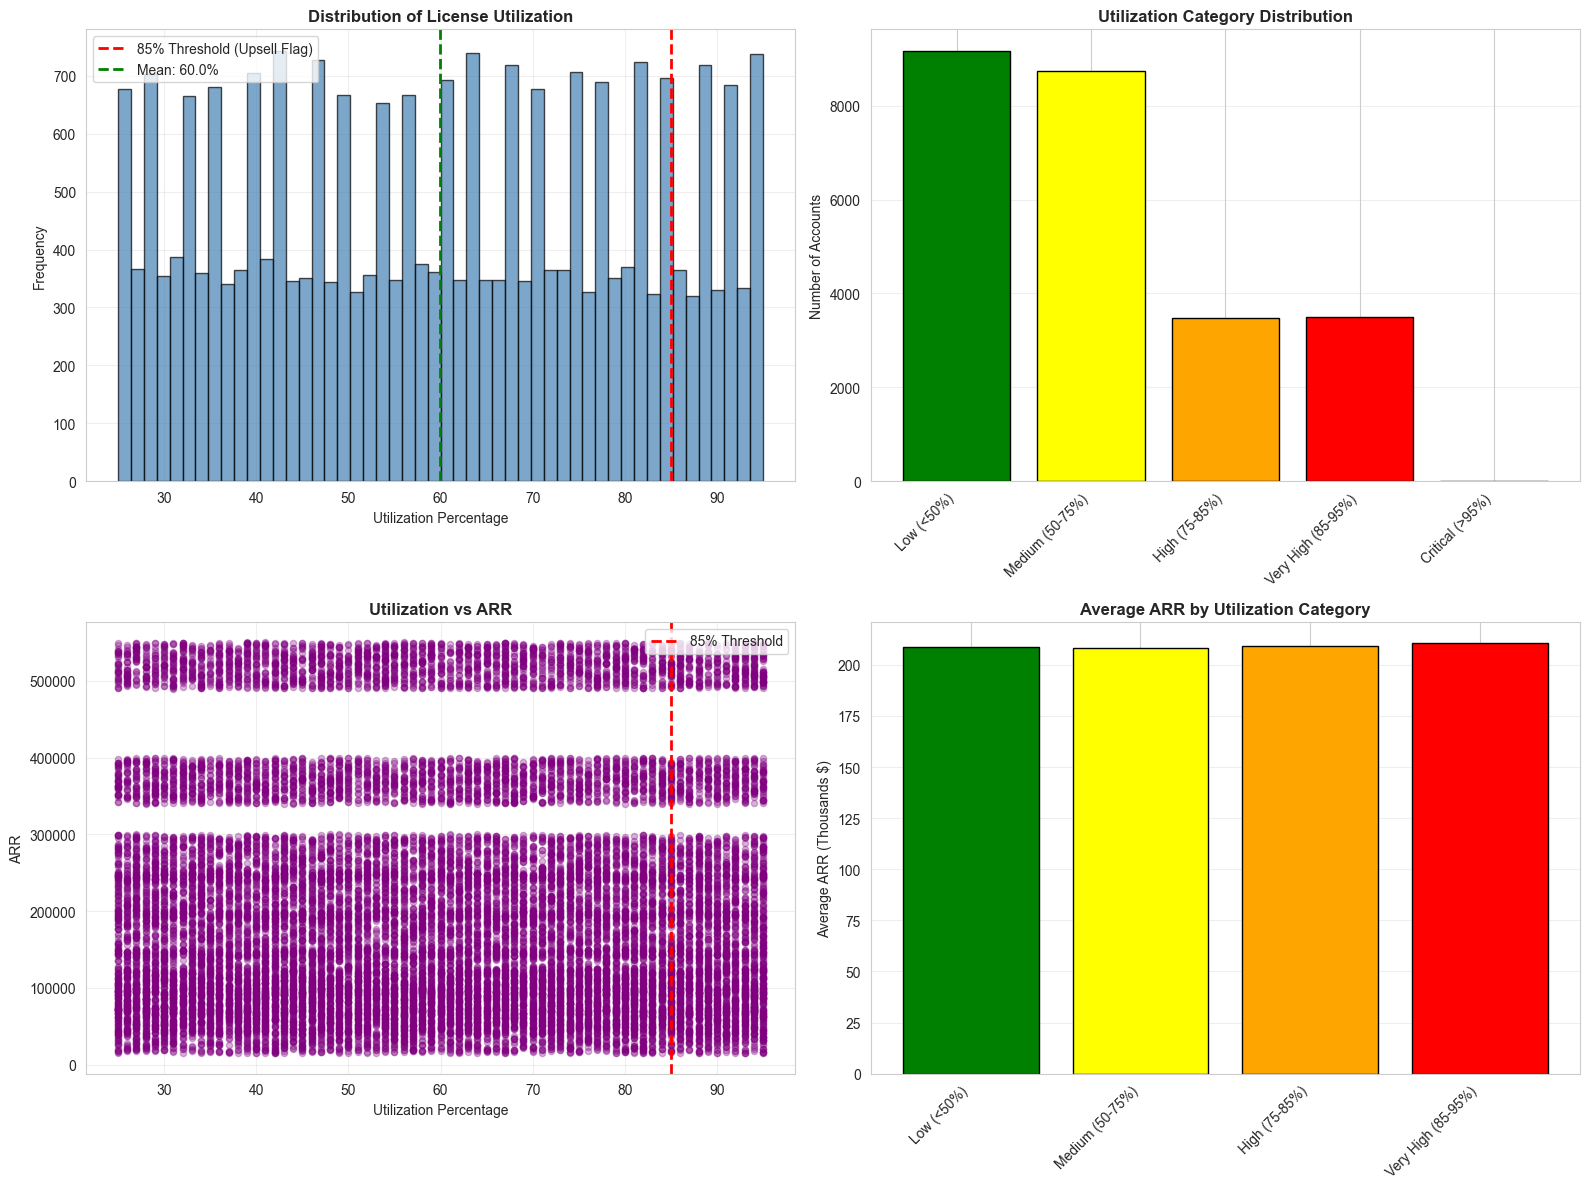

LICENSE UTILIZATION SUMMARY

Average Utilization: 59.96%
Median Utilization: 60.00%

Utilization Category Distribution:
utilization_category
Low (<50%)            9167
Medium (50-75%)       8738
High (75-85%)         3480
Very High (85-95%)    3489
Critical (>95%)          0
Name: count, dtype: int64

🚨 HIGH UTILIZATION ACCOUNTS (≥85%) - Seat Expansion Opportunity:
   Count: 3,821 (15.4%)
   Total ARR: $807,496,331.00
   Average ARR: $211,331.15
   Potential ARR Increase: $89,988,655.43


In [9]:
# License utilization distribution
if 'utilization_percentage' in df_upsell.columns:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Distribution of utilization
    axes[0, 0].hist(df_upsell['utilization_percentage'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[0, 0].axvline(85, color='red', linestyle='--', linewidth=2, label='85% Threshold (Upsell Flag)')
    axes[0, 0].axvline(df_upsell['utilization_percentage'].mean(), color='green', linestyle='--', 
                       linewidth=2, label=f'Mean: {df_upsell["utilization_percentage"].mean():.1f}%')
    axes[0, 0].set_xlabel('Utilization Percentage', fontsize=10)
    axes[0, 0].set_ylabel('Frequency', fontsize=10)
    axes[0, 0].set_title('Distribution of License Utilization', fontsize=12, fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Utilization categories
    # Handle any NaN or out-of-range values
    util_clean = df_upsell['utilization_percentage'].fillna(0).clip(0, 100)
    df_upsell['utilization_category'] = pd.cut(
        util_clean,
        bins=[0, 50, 75, 85, 95, 100],
        labels=['Low (<50%)', 'Medium (50-75%)', 'High (75-85%)', 'Very High (85-95%)', 'Critical (>95%)'],
        include_lowest=True
    )
    
    util_counts = df_upsell['utilization_category'].value_counts().sort_index()
    colors = ['green', 'yellow', 'orange', 'red', 'darkred']
    axes[0, 1].bar(range(len(util_counts)), util_counts.values, 
                   color=colors[:len(util_counts)], edgecolor='black')
    axes[0, 1].set_xticks(range(len(util_counts)))
    axes[0, 1].set_xticklabels(util_counts.index, rotation=45, ha='right')
    axes[0, 1].set_ylabel('Number of Accounts', fontsize=10)
    axes[0, 1].set_title('Utilization Category Distribution', fontsize=12, fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    
    # Utilization vs ARR
    if 'arr' in df_upsell.columns:
        axes[1, 0].scatter(df_upsell['utilization_percentage'], df_upsell['arr'], 
                          alpha=0.3, s=20, color='purple')
        axes[1, 0].axvline(85, color='red', linestyle='--', linewidth=2, label='85% Threshold')
        axes[1, 0].set_xlabel('Utilization Percentage', fontsize=10)
        axes[1, 0].set_ylabel('ARR', fontsize=10)
        axes[1, 0].set_title('Utilization vs ARR', fontsize=12, fontweight='bold')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
    
    # Average ARR by utilization category
    if 'arr' in df_upsell.columns:
        arr_by_util = df_upsell.groupby('utilization_category')['arr'].mean()
        axes[1, 1].bar(range(len(arr_by_util)), arr_by_util.values / 1000, 
                      color=colors[:len(arr_by_util)], edgecolor='black')
        axes[1, 1].set_xticks(range(len(arr_by_util)))
        axes[1, 1].set_xticklabels(arr_by_util.index, rotation=45, ha='right')
        axes[1, 1].set_ylabel('Average ARR (Thousands $)', fontsize=10)
        axes[1, 1].set_title('Average ARR by Utilization Category', fontsize=12, fontweight='bold')
        axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    print("=" * 80)
    print("LICENSE UTILIZATION SUMMARY")
    print("=" * 80)
    print(f"\nAverage Utilization: {df_upsell['utilization_percentage'].mean():.2f}%")
    print(f"Median Utilization: {df_upsell['utilization_percentage'].median():.2f}%")
    print(f"\nUtilization Category Distribution:")
    print(df_upsell['utilization_category'].value_counts().sort_index())
    
    # High utilization accounts (upsell opportunity)
    high_util = df_upsell[df_upsell['utilization_percentage'] >= 85]
    print(f"\n🚨 HIGH UTILIZATION ACCOUNTS (≥85%) - Seat Expansion Opportunity:")
    print(f"   Count: {len(high_util):,} ({len(high_util)/len(df_upsell)*100:.1f}%)")
    if 'arr' in df_upsell.columns:
        print(f"   Total ARR: ${high_util['arr'].sum():,.2f}")
        print(f"   Average ARR: ${high_util['arr'].mean():,.2f}")
    if 'potential_arr_increase' in df_upsell.columns:
        print(f"   Potential ARR Increase: ${high_util['potential_arr_increase'].sum():,.2f}")

## 4. Rule-Based Upsell Opportunity Flags

In [10]:
# Apply rule-based logic for upsell opportunities
print("=" * 80)
print("RULE-BASED UPSELL OPPORTUNITY DETECTION")
print("=" * 80)

# Rule 1: High License Utilization (>85%) → Seat Expansion
if 'utilization_percentage' in df_upsell.columns:
    df_upsell['flag_seat_expansion'] = df_upsell['utilization_percentage'] >= 85
    seat_expansion_count = df_upsell['flag_seat_expansion'].sum()
    print(f"\n✅ Rule 1: License Utilization > 85% → Seat Expansion")
    print(f"   Flagged Accounts: {seat_expansion_count:,} ({seat_expansion_count/len(df_upsell)*100:.1f}%)")
    if 'arr' in df_upsell.columns:
        seat_expansion_arr = df_upsell[df_upsell['flag_seat_expansion']]['arr'].sum()
        print(f"   Total ARR: ${seat_expansion_arr:,.2f}")

# Rule 2: Account Growth Potential (High utilization + Good health)
if 'utilization_percentage' in df_upsell.columns and 'health_score' in df_upsell.columns:
    df_upsell['flag_capacity_increase'] = (
        (df_upsell['utilization_percentage'] >= 75) & 
        (df_upsell['health_score'] >= 70)
    )
    capacity_increase_count = df_upsell['flag_capacity_increase'].sum()
    print(f"\n✅ Rule 2: Utilization ≥75% + Health Score ≥70 → Capacity Increase")
    print(f"   Flagged Accounts: {capacity_increase_count:,} ({capacity_increase_count/len(df_upsell)*100:.1f}%)")
    if 'arr' in df_upsell.columns:
        capacity_arr = df_upsell[df_upsell['flag_capacity_increase']]['arr'].sum()
        print(f"   Total ARR: ${capacity_arr:,.2f}")

# Rule 3: High ARR + Low Utilization → Tier Upgrade Opportunity
if 'arr' in df_upsell.columns and 'utilization_percentage' in df_upsell.columns:
    arr_median = df_upsell['arr'].median()
    df_upsell['flag_tier_upgrade'] = (
        (df_upsell['arr'] >= arr_median) & 
        (df_upsell['utilization_percentage'] < 50)
    )
    tier_upgrade_count = df_upsell['flag_tier_upgrade'].sum()
    print(f"\n✅ Rule 3: High ARR (≥${arr_median:,.0f}) + Low Utilization (<50%) → Tier Upgrade")
    print(f"   Flagged Accounts: {tier_upgrade_count:,} ({tier_upgrade_count/len(df_upsell)*100:.1f}%)")
    if 'arr' in df_upsell.columns:
        tier_upgrade_arr = df_upsell[df_upsell['flag_tier_upgrade']]['arr'].sum()
        print(f"   Total ARR: ${tier_upgrade_arr:,.2f}")

# Rule 4: Contract Maturity + High Health → Expansion Ready
if ('contract_duration_months' in df_upsell.columns and 
    'health_score' in df_upsell.columns and 
    'utilization_percentage' in df_upsell.columns):
    df_upsell['flag_expansion_ready'] = (
        (df_upsell['contract_duration_months'] >= 12) & 
        (df_upsell['health_score'] >= 75) &
        (df_upsell['utilization_percentage'] >= 70)
    )
    expansion_ready_count = df_upsell['flag_expansion_ready'].sum()
    print(f"\n✅ Rule 4: Contract ≥12 months + Health ≥75 + Utilization ≥70% → Expansion Ready")
    print(f"   Flagged Accounts: {expansion_ready_count:,} ({expansion_ready_count/len(df_upsell)*100:.1f}%)")
    if 'arr' in df_upsell.columns:
        expansion_ready_arr = df_upsell[df_upsell['flag_expansion_ready']]['arr'].sum()
        print(f"   Total ARR: ${expansion_ready_arr:,.2f}")

# Create overall upsell opportunity score
upsell_flags = ['flag_seat_expansion', 'flag_capacity_increase', 
                'flag_tier_upgrade', 'flag_expansion_ready']
available_flags = [f for f in upsell_flags if f in df_upsell.columns]

if available_flags:
    df_upsell['upsell_opportunity_score'] = df_upsell[available_flags].sum(axis=1)
    df_upsell['has_upsell_opportunity'] = df_upsell['upsell_opportunity_score'] > 0
    
    total_opportunities = df_upsell['has_upsell_opportunity'].sum()
    print(f"\n🎯 TOTAL ACCOUNTS WITH UPSELL OPPORTUNITIES: {total_opportunities:,} ({total_opportunities/len(df_upsell)*100:.1f}%)")
    if 'arr' in df_upsell.columns:
        total_opportunity_arr = df_upsell[df_upsell['has_upsell_opportunity']]['arr'].sum()
        print(f"   Total ARR at Opportunity: ${total_opportunity_arr:,.2f}")
    
    print(f"\nOpportunity Score Distribution:")
    print(df_upsell['upsell_opportunity_score'].value_counts().sort_index())

RULE-BASED UPSELL OPPORTUNITY DETECTION

✅ Rule 1: License Utilization > 85% → Seat Expansion
   Flagged Accounts: 3,821 (15.4%)
   Total ARR: $807,496,331.00

✅ Rule 2: Utilization ≥75% + Health Score ≥70 → Capacity Increase
   Flagged Accounts: 4,219 (17.0%)
   Total ARR: $1,258,053,667.00

✅ Rule 3: High ARR (≥$170,628) + Low Utilization (<50%) → Tier Upgrade
   Flagged Accounts: 4,463 (17.9%)
   Total ARR: $1,451,560,462.00

✅ Rule 4: Contract ≥12 months + Health ≥75 + Utilization ≥70% → Expansion Ready
   Flagged Accounts: 0 (0.0%)
   Total ARR: $0.00

🎯 TOTAL ACCOUNTS WITH UPSELL OPPORTUNITIES: 10,280 (41.3%)
   Total ARR at Opportunity: $2,852,657,430.00

Opportunity Score Distribution:
upsell_opportunity_score
0    14594
1     8057
2     2223
Name: count, dtype: int64


## 5. Industry Benchmark Analysis

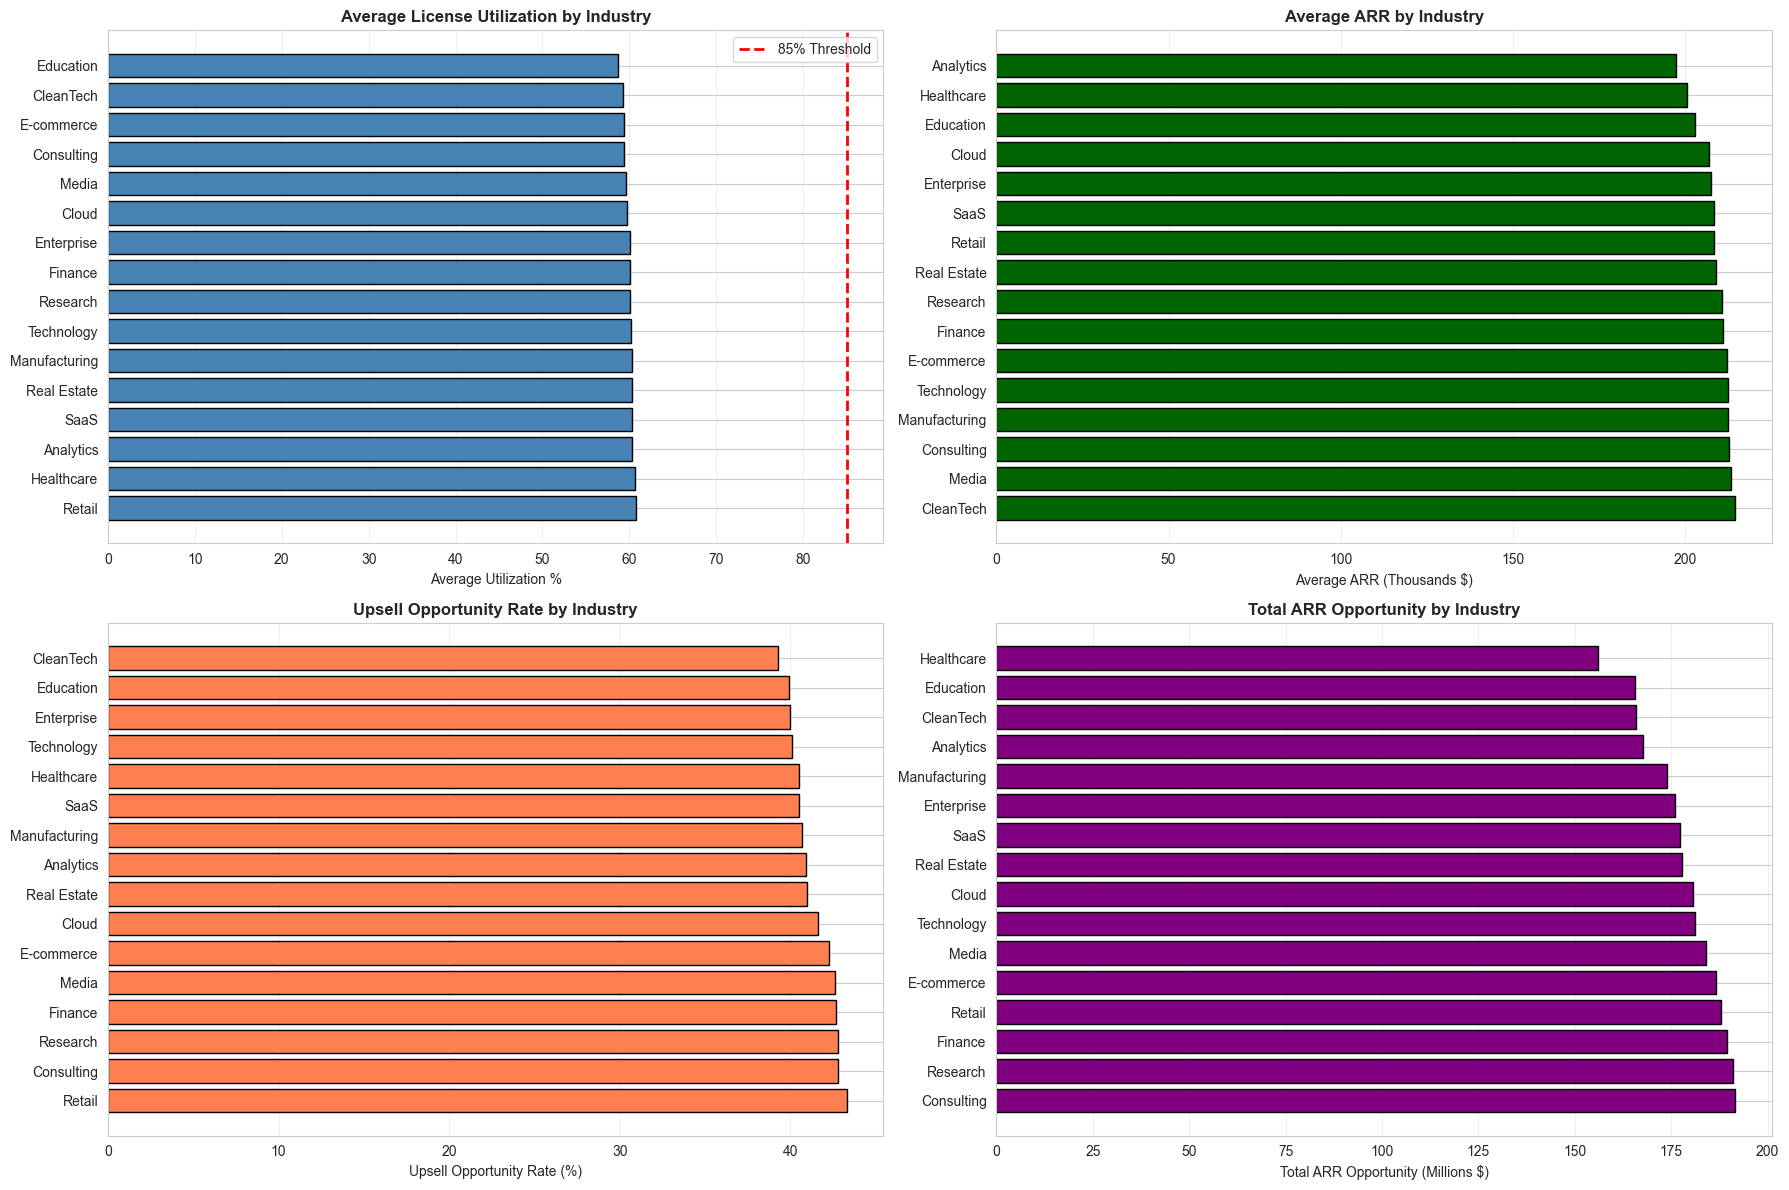

INDUSTRY BENCHMARKS

Average Utilization by Industry:
               Mean Utilization %  Median Utilization %  Account Count
industry                                                              
Retail                      60.76                  61.0           1569
Healthcare                  60.71                  61.0           1475
Analytics                   60.31                  60.0           1613
SaaS                        60.31                  61.0           1574
Real Estate                 60.29                  60.0           1557
Manufacturing               60.27                  60.0           1486
Technology                  60.21                  61.0           1592
Research                    60.11                  61.0           1611
Finance                     60.07                  60.0           1578
Enterprise                  60.03                  60.0           1568
Cloud                       59.76                  60.0           1585
Media                  

In [11]:
# Industry benchmarks for utilization and ARR
if 'industry' in df_upsell.columns:
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    
    # Average utilization by industry
    if 'utilization_percentage' in df_upsell.columns:
        industry_util = df_upsell.groupby('industry')['utilization_percentage'].mean().sort_values(ascending=False)
        axes[0, 0].barh(range(len(industry_util)), industry_util.values, color='steelblue', edgecolor='black')
        axes[0, 0].set_yticks(range(len(industry_util)))
        axes[0, 0].set_yticklabels(industry_util.index)
        axes[0, 0].axvline(85, color='red', linestyle='--', linewidth=2, label='85% Threshold')
        axes[0, 0].set_xlabel('Average Utilization %', fontsize=10)
        axes[0, 0].set_title('Average License Utilization by Industry', fontsize=12, fontweight='bold')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3, axis='x')
    
    # Average ARR by industry
    if 'arr' in df_upsell.columns:
        industry_arr = df_upsell.groupby('industry')['arr'].mean().sort_values(ascending=False)
        axes[0, 1].barh(range(len(industry_arr)), industry_arr.values / 1000, 
                       color='darkgreen', edgecolor='black')
        axes[0, 1].set_yticks(range(len(industry_arr)))
        axes[0, 1].set_yticklabels(industry_arr.index)
        axes[0, 1].set_xlabel('Average ARR (Thousands $)', fontsize=10)
        axes[0, 1].set_title('Average ARR by Industry', fontsize=12, fontweight='bold')
        axes[0, 1].grid(True, alpha=0.3, axis='x')
    
    # Upsell opportunities by industry
    if 'has_upsell_opportunity' in df_upsell.columns:
        industry_opportunities = df_upsell.groupby('industry')['has_upsell_opportunity'].agg(['sum', 'count'])
        industry_opportunities['pct'] = (industry_opportunities['sum'] / industry_opportunities['count'] * 100).round(1)
        industry_opportunities = industry_opportunities.sort_values('pct', ascending=False)
        
        axes[1, 0].barh(range(len(industry_opportunities)), industry_opportunities['pct'].values,
                        color='coral', edgecolor='black')
        axes[1, 0].set_yticks(range(len(industry_opportunities)))
        axes[1, 0].set_yticklabels(industry_opportunities.index)
        axes[1, 0].set_xlabel('Upsell Opportunity Rate (%)', fontsize=10)
        axes[1, 0].set_title('Upsell Opportunity Rate by Industry', fontsize=12, fontweight='bold')
        axes[1, 0].grid(True, alpha=0.3, axis='x')
    
    # Total ARR opportunity by industry
    if 'arr' in df_upsell.columns and 'has_upsell_opportunity' in df_upsell.columns:
        industry_arr_opp = df_upsell[df_upsell['has_upsell_opportunity']].groupby('industry')['arr'].sum().sort_values(ascending=False)
        axes[1, 1].barh(range(len(industry_arr_opp)), industry_arr_opp.values / 1e6,
                       color='purple', edgecolor='black')
        axes[1, 1].set_yticks(range(len(industry_arr_opp)))
        axes[1, 1].set_yticklabels(industry_arr_opp.index)
        axes[1, 1].set_xlabel('Total ARR Opportunity (Millions $)', fontsize=10)
        axes[1, 1].set_title('Total ARR Opportunity by Industry', fontsize=12, fontweight='bold')
        axes[1, 1].grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()
    
    # Print industry benchmarks
    print("=" * 80)
    print("INDUSTRY BENCHMARKS")
    print("=" * 80)
    if 'utilization_percentage' in df_upsell.columns:
        print("\nAverage Utilization by Industry:")
        industry_stats = df_upsell.groupby('industry')['utilization_percentage'].agg(['mean', 'median', 'count'])
        industry_stats.columns = ['Mean Utilization %', 'Median Utilization %', 'Account Count']
        print(industry_stats.sort_values('Mean Utilization %', ascending=False).round(2))

## 6. Account Health & Sentiment Analysis for Upsell Readiness

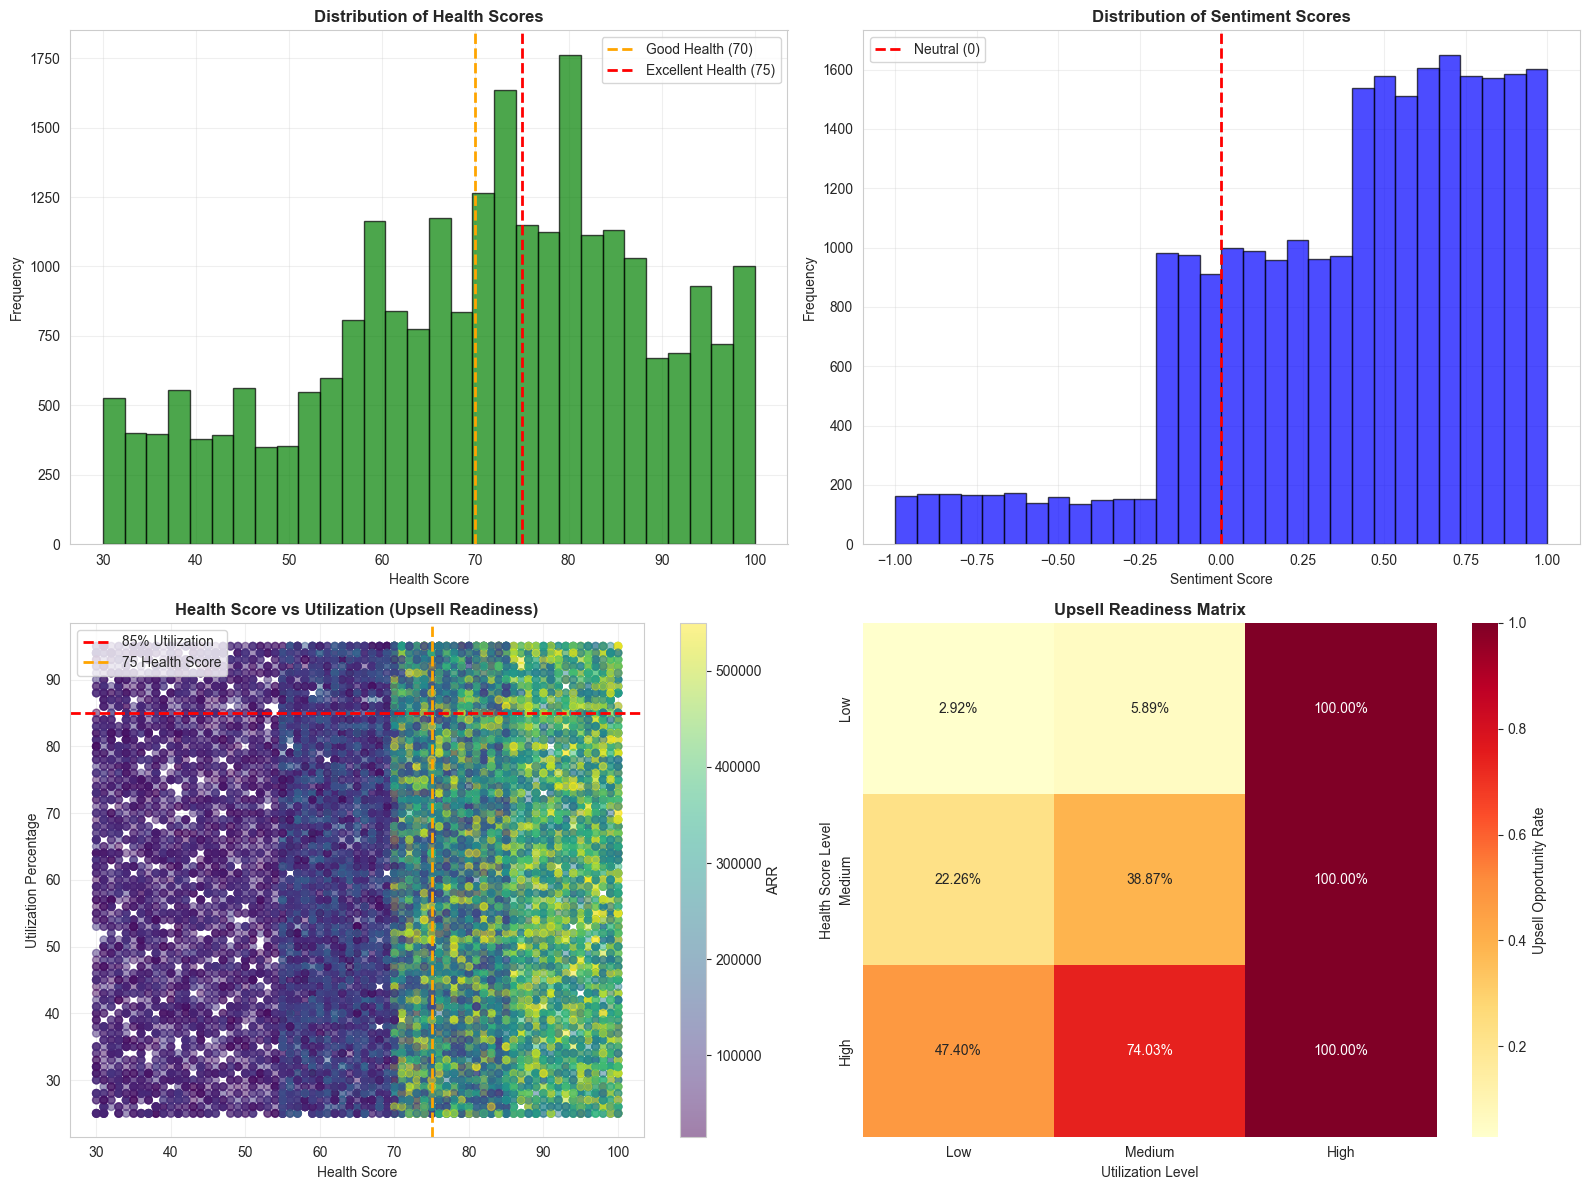

HIGH READINESS ACCOUNTS FOR UPSELL
Count: 3,370 accounts
Total ARR: $1,038,055,451.00
Average ARR: $308,028.32


In [12]:
# Analyze health and sentiment scores for upsell readiness
if 'health_score' in df_upsell.columns and 'sentiment_score' in df_upsell.columns:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Health score distribution
    axes[0, 0].hist(df_upsell['health_score'], bins=30, edgecolor='black', alpha=0.7, color='green')
    axes[0, 0].axvline(70, color='orange', linestyle='--', linewidth=2, label='Good Health (70)')
    axes[0, 0].axvline(75, color='red', linestyle='--', linewidth=2, label='Excellent Health (75)')
    axes[0, 0].set_xlabel('Health Score', fontsize=10)
    axes[0, 0].set_ylabel('Frequency', fontsize=10)
    axes[0, 0].set_title('Distribution of Health Scores', fontsize=12, fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Sentiment score distribution
    axes[0, 1].hist(df_upsell['sentiment_score'], bins=30, edgecolor='black', alpha=0.7, color='blue')
    axes[0, 1].axvline(0, color='red', linestyle='--', linewidth=2, label='Neutral (0)')
    axes[0, 1].set_xlabel('Sentiment Score', fontsize=10)
    axes[0, 1].set_ylabel('Frequency', fontsize=10)
    axes[0, 1].set_title('Distribution of Sentiment Scores', fontsize=12, fontweight='bold')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Health vs Utilization (upsell readiness)
    if 'utilization_percentage' in df_upsell.columns:
        scatter = axes[1, 0].scatter(df_upsell['health_score'], df_upsell['utilization_percentage'],
                                     c=df_upsell.get('arr', 0), cmap='viridis', alpha=0.5, s=30)
        axes[1, 0].axhline(85, color='red', linestyle='--', linewidth=2, label='85% Utilization')
        axes[1, 0].axvline(75, color='orange', linestyle='--', linewidth=2, label='75 Health Score')
        axes[1, 0].set_xlabel('Health Score', fontsize=10)
        axes[1, 0].set_ylabel('Utilization Percentage', fontsize=10)
        axes[1, 0].set_title('Health Score vs Utilization (Upsell Readiness)', fontsize=12, fontweight='bold')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
        if 'arr' in df_upsell.columns:
            plt.colorbar(scatter, ax=axes[1, 0], label='ARR')
    
    # Upsell readiness matrix
    if 'has_upsell_opportunity' in df_upsell.columns:
        # Clean data before creating bins
        health_clean = df_upsell['health_score'].fillna(0).clip(0, 100)
        util_clean = df_upsell['utilization_percentage'].fillna(0).clip(0, 100)
        
        try:
            readiness = df_upsell.groupby([
                pd.cut(health_clean, bins=[0, 60, 75, 100], labels=['Low', 'Medium', 'High'], include_lowest=True),
                pd.cut(util_clean, bins=[0, 70, 85, 100], labels=['Low', 'Medium', 'High'], include_lowest=True)
            ])['has_upsell_opportunity'].mean().unstack()
            
            sns.heatmap(readiness, annot=True, fmt='.2%', cmap='YlOrRd', ax=axes[1, 1],
                       cbar_kws={'label': 'Upsell Opportunity Rate'})
            axes[1, 1].set_xlabel('Utilization Level', fontsize=10)
            axes[1, 1].set_ylabel('Health Score Level', fontsize=10)
            axes[1, 1].set_title('Upsell Readiness Matrix', fontsize=12, fontweight='bold')
        except Exception as e:
            print(f"Could not create readiness matrix: {e}")
            axes[1, 1].text(0.5, 0.5, 'Data insufficient\nfor readiness matrix', 
                           ha='center', va='center', transform=axes[1, 1].transAxes)
            axes[1, 1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # High readiness accounts
    if 'has_upsell_opportunity' in df_upsell.columns:
        high_readiness = df_upsell[
            (df_upsell['health_score'] >= 75) & 
            (df_upsell['utilization_percentage'] >= 70) &
            (df_upsell['has_upsell_opportunity'] == True)
        ]
        print("=" * 80)
        print("HIGH READINESS ACCOUNTS FOR UPSELL")
        print("=" * 80)
        print(f"Count: {len(high_readiness):,} accounts")
        if 'arr' in df_upsell.columns:
            print(f"Total ARR: ${high_readiness['arr'].sum():,.2f}")
            print(f"Average ARR: ${high_readiness['arr'].mean():,.2f}")

## 7. Contract Duration & Maturity Analysis

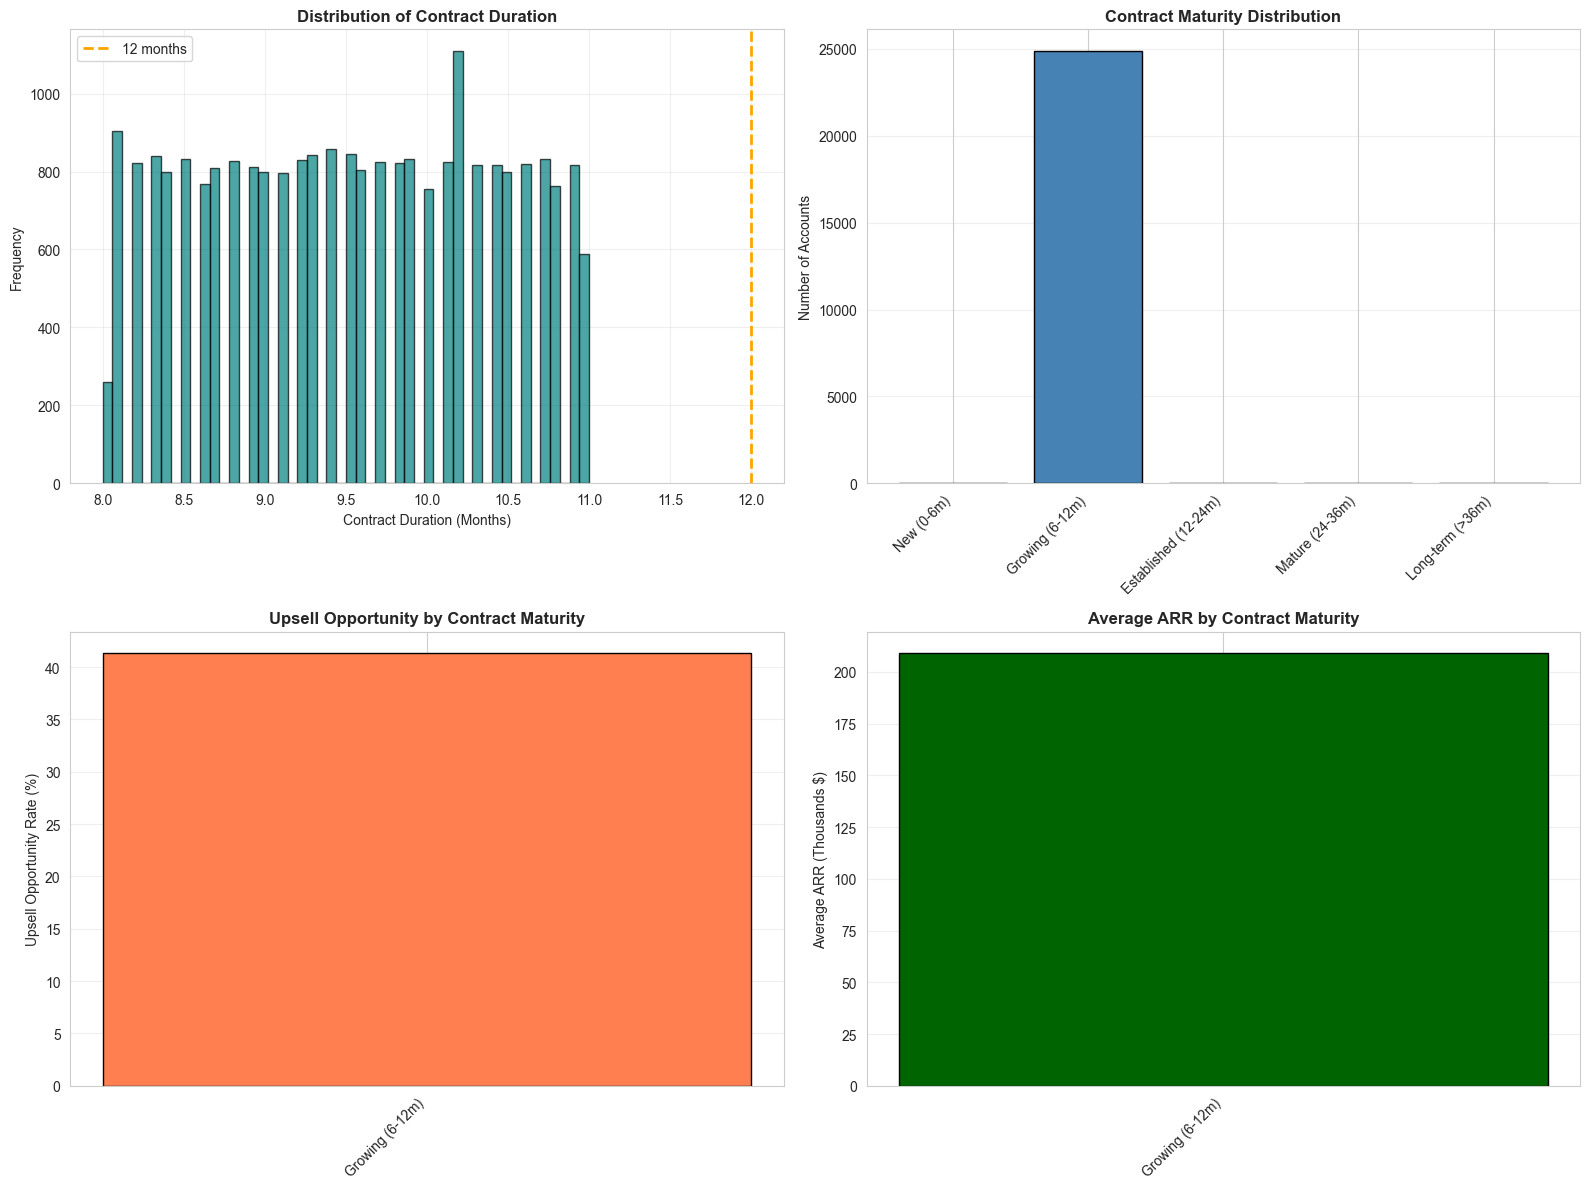

CONTRACT MATURITY ANALYSIS

Average Contract Duration: 9.5 months
Median Contract Duration: 9.5 months

Maturity Distribution:
contract_maturity
New (0-6m)                  0
Growing (6-12m)         24874
Established (12-24m)        0
Mature (24-36m)             0
Long-term (>36m)            0
Name: count, dtype: int64


In [13]:
# Analyze contract duration and maturity
if 'contract_duration_months' in df_upsell.columns:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Contract duration distribution
    axes[0, 0].hist(df_upsell['contract_duration_months'].dropna(), bins=50, 
                    edgecolor='black', alpha=0.7, color='teal')
    axes[0, 0].axvline(12, color='orange', linestyle='--', linewidth=2, label='12 months')
    axes[0, 0].set_xlabel('Contract Duration (Months)', fontsize=10)
    axes[0, 0].set_ylabel('Frequency', fontsize=10)
    axes[0, 0].set_title('Distribution of Contract Duration', fontsize=12, fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Contract maturity categories
    # Handle any NaN values
    duration_clean = df_upsell['contract_duration_months'].fillna(0).clip(lower=0)
    df_upsell['contract_maturity'] = pd.cut(
        duration_clean,
        bins=[0, 6, 12, 24, 36, float('inf')],
        labels=['New (0-6m)', 'Growing (6-12m)', 'Established (12-24m)', 
                'Mature (24-36m)', 'Long-term (>36m)'],
        include_lowest=True
    )
    
    maturity_counts = df_upsell['contract_maturity'].value_counts().sort_index()
    axes[0, 1].bar(range(len(maturity_counts)), maturity_counts.values,
                   color='steelblue', edgecolor='black')
    axes[0, 1].set_xticks(range(len(maturity_counts)))
    axes[0, 1].set_xticklabels(maturity_counts.index, rotation=45, ha='right')
    axes[0, 1].set_ylabel('Number of Accounts', fontsize=10)
    axes[0, 1].set_title('Contract Maturity Distribution', fontsize=12, fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    
    # Upsell opportunities by contract maturity
    if 'has_upsell_opportunity' in df_upsell.columns:
        maturity_opp = df_upsell.groupby('contract_maturity')['has_upsell_opportunity'].agg(['sum', 'count'])
        maturity_opp['pct'] = (maturity_opp['sum'] / maturity_opp['count'] * 100).round(1)
        maturity_opp = maturity_opp.sort_index()
        
        axes[1, 0].bar(range(len(maturity_opp)), maturity_opp['pct'].values,
                      color='coral', edgecolor='black')
        axes[1, 0].set_xticks(range(len(maturity_opp)))
        axes[1, 0].set_xticklabels(maturity_opp.index, rotation=45, ha='right')
        axes[1, 0].set_ylabel('Upsell Opportunity Rate (%)', fontsize=10)
        axes[1, 0].set_title('Upsell Opportunity by Contract Maturity', fontsize=12, fontweight='bold')
        axes[1, 0].grid(True, alpha=0.3, axis='y')
    
    # Average ARR by contract maturity
    if 'arr' in df_upsell.columns:
        arr_by_maturity = df_upsell.groupby('contract_maturity')['arr'].mean().sort_index()
        axes[1, 1].bar(range(len(arr_by_maturity)), arr_by_maturity.values / 1000,
                      color='darkgreen', edgecolor='black')
        axes[1, 1].set_xticks(range(len(arr_by_maturity)))
        axes[1, 1].set_xticklabels(arr_by_maturity.index, rotation=45, ha='right')
        axes[1, 1].set_ylabel('Average ARR (Thousands $)', fontsize=10)
        axes[1, 1].set_title('Average ARR by Contract Maturity', fontsize=12, fontweight='bold')
        axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    print("=" * 80)
    print("CONTRACT MATURITY ANALYSIS")
    print("=" * 80)
    print(f"\nAverage Contract Duration: {df_upsell['contract_duration_months'].mean():.1f} months")
    print(f"Median Contract Duration: {df_upsell['contract_duration_months'].median():.1f} months")
    print(f"\nMaturity Distribution:")
    print(df_upsell['contract_maturity'].value_counts().sort_index())

## 8. Potential Revenue Opportunity Analysis

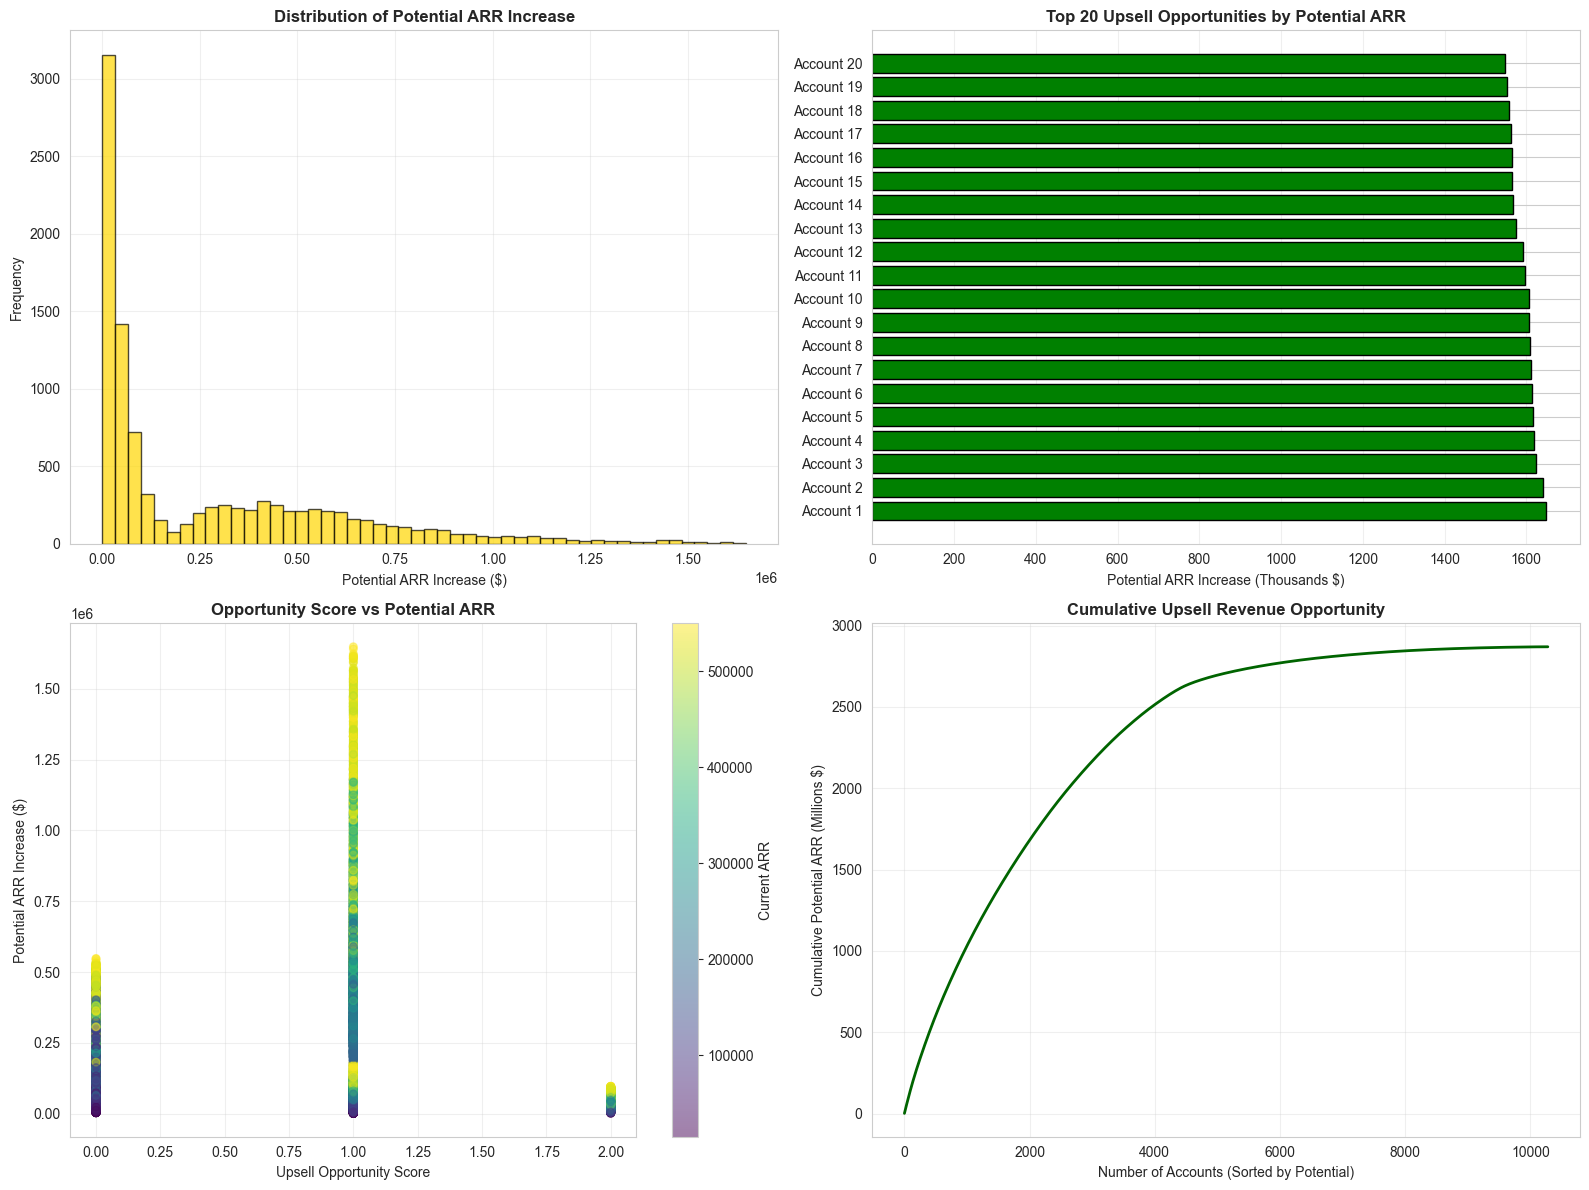

REVENUE OPPORTUNITY SUMMARY

💰 Total Potential ARR Increase: $2,869,605,520.53
   Average per Opportunity: $279,144.51
   Median per Opportunity: $89,302.24

🏆 Top 10 Upsell Opportunities:
                          name    arr  utilization_percentage  health_score  potential_arr_increase  upsell_opportunity_score
                   Lindsey Inc 549586                      25            84               1648758.0                         1
Williams, Edwards and Mcdaniel 547002                      25            72               1641006.0                         1
                  Lawson Group 541275                      25            87               1623825.0                         1
                      Hill LLC 539281                      25            71               1617843.0                         1
               Landry-Cummings 538542                      25            84               1615626.0                         1
      Johnson, Lowe and Wright 538213                  

In [14]:
# Calculate potential revenue opportunities
if 'potential_arr_increase' in df_upsell.columns and 'has_upsell_opportunity' in df_upsell.columns:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Potential ARR increase distribution
    potential_arr = df_upsell[df_upsell['has_upsell_opportunity']]['potential_arr_increase']
    axes[0, 0].hist(potential_arr[potential_arr > 0], bins=50, edgecolor='black', alpha=0.7, color='gold')
    axes[0, 0].set_xlabel('Potential ARR Increase ($)', fontsize=10)
    axes[0, 0].set_ylabel('Frequency', fontsize=10)
    axes[0, 0].set_title('Distribution of Potential ARR Increase', fontsize=12, fontweight='bold')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Top opportunities by potential ARR
    top_opportunities = df_upsell[df_upsell['has_upsell_opportunity']].nlargest(20, 'potential_arr_increase')
    if len(top_opportunities) > 0:
        axes[0, 1].barh(range(len(top_opportunities)), 
                       top_opportunities['potential_arr_increase'].values / 1000,
                       color='green', edgecolor='black')
        axes[0, 1].set_yticks(range(len(top_opportunities)))
        axes[0, 1].set_yticklabels([f"Account {i+1}" for i in range(len(top_opportunities))])
        axes[0, 1].set_xlabel('Potential ARR Increase (Thousands $)', fontsize=10)
        axes[0, 1].set_title('Top 20 Upsell Opportunities by Potential ARR', fontsize=12, fontweight='bold')
        axes[0, 1].grid(True, alpha=0.3, axis='x')
    
    # Opportunity score vs potential ARR
    if 'upsell_opportunity_score' in df_upsell.columns:
        scatter = axes[1, 0].scatter(df_upsell['upsell_opportunity_score'], 
                                    df_upsell['potential_arr_increase'],
                                    alpha=0.5, s=30, c=df_upsell.get('arr', 0), cmap='viridis')
        axes[1, 0].set_xlabel('Upsell Opportunity Score', fontsize=10)
        axes[1, 0].set_ylabel('Potential ARR Increase ($)', fontsize=10)
        axes[1, 0].set_title('Opportunity Score vs Potential ARR', fontsize=12, fontweight='bold')
        axes[1, 0].grid(True, alpha=0.3)
        if 'arr' in df_upsell.columns:
            plt.colorbar(scatter, ax=axes[1, 0], label='Current ARR')
    
    # Cumulative opportunity
    sorted_opp = df_upsell[df_upsell['has_upsell_opportunity']].sort_values('potential_arr_increase', ascending=False)
    if len(sorted_opp) > 0:
        cumulative_arr = sorted_opp['potential_arr_increase'].cumsum()
        axes[1, 1].plot(range(len(cumulative_arr)), cumulative_arr / 1e6, 
                       linewidth=2, color='darkgreen')
        axes[1, 1].set_xlabel('Number of Accounts (Sorted by Potential)', fontsize=10)
        axes[1, 1].set_ylabel('Cumulative Potential ARR (Millions $)', fontsize=10)
        axes[1, 1].set_title('Cumulative Upsell Revenue Opportunity', fontsize=12, fontweight='bold')
        axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    print("=" * 80)
    print("REVENUE OPPORTUNITY SUMMARY")
    print("=" * 80)
    total_potential = df_upsell[df_upsell['has_upsell_opportunity']]['potential_arr_increase'].sum()
    print(f"\n💰 Total Potential ARR Increase: ${total_potential:,.2f}")
    print(f"   Average per Opportunity: ${df_upsell[df_upsell['has_upsell_opportunity']]['potential_arr_increase'].mean():,.2f}")
    print(f"   Median per Opportunity: ${df_upsell[df_upsell['has_upsell_opportunity']]['potential_arr_increase'].median():,.2f}")
    
    # Top 10 opportunities
    print(f"\n🏆 Top 10 Upsell Opportunities:")
    top_10_cols = ['name', 'arr', 'utilization_percentage', 'health_score', 'potential_arr_increase', 'upsell_opportunity_score']
    available_cols = [col for col in top_10_cols if col in df_upsell.columns]
    if len(available_cols) > 0:
        top_10 = df_upsell[df_upsell['has_upsell_opportunity']].nlargest(10, 'potential_arr_increase')[available_cols]
        print(top_10.to_string(index=False))
    else:
        print("Required columns not available for top opportunities display.")

## 9. Summary & Key Insights

In [15]:
# Final summary and insights
print("=" * 80)
print("UPSELL OPPORTUNITY DETECTION - FINAL SUMMARY")
print("=" * 80)

# Overall statistics
total_accounts = len(df_upsell)
if 'has_upsell_opportunity' in df_upsell.columns:
    opportunity_accounts = df_upsell['has_upsell_opportunity'].sum()
    print(f"\n📊 Total Accounts Analyzed: {total_accounts:,}")
    print(f"🎯 Accounts with Upsell Opportunities: {opportunity_accounts:,} ({opportunity_accounts/total_accounts*100:.1f}%)")

# Revenue metrics
if 'arr' in df_upsell.columns:
    total_arr = df_upsell['arr'].sum()
    opportunity_arr = df_upsell[df_upsell['has_upsell_opportunity']]['arr'].sum() if 'has_upsell_opportunity' in df_upsell.columns else 0
    print(f"\n💰 Revenue Metrics:")
    print(f"   Total ARR: ${total_arr:,.2f}")
    print(f"   ARR at Opportunity: ${opportunity_arr:,.2f} ({opportunity_arr/total_arr*100:.1f}% of total)")
    if 'potential_arr_increase' in df_upsell.columns:
        potential_increase = df_upsell[df_upsell['has_upsell_opportunity']]['potential_arr_increase'].sum()
        print(f"   Potential ARR Increase: ${potential_increase:,.2f}")

# Opportunity breakdown by type
if 'flag_seat_expansion' in df_upsell.columns:
    print(f"\n🔍 Opportunity Breakdown:")
    print(f"   Seat Expansion (Utilization ≥85%): {df_upsell['flag_seat_expansion'].sum():,} accounts")
if 'flag_capacity_increase' in df_upsell.columns:
    print(f"   Capacity Increase (Util ≥75% + Health ≥70): {df_upsell['flag_capacity_increase'].sum():,} accounts")
if 'flag_tier_upgrade' in df_upsell.columns:
    print(f"   Tier Upgrade (High ARR + Low Util): {df_upsell['flag_tier_upgrade'].sum():,} accounts")
if 'flag_expansion_ready' in df_upsell.columns:
    print(f"   Expansion Ready (Mature + Healthy): {df_upsell['flag_expansion_ready'].sum():,} accounts")

# Industry insights
if 'industry' in df_upsell.columns and 'has_upsell_opportunity' in df_upsell.columns:
    industry_insights = df_upsell.groupby('industry').agg({
        'has_upsell_opportunity': 'sum',
        'arr': 'sum'
    })
    industry_insights['opportunity_rate'] = (
        industry_insights['has_upsell_opportunity'] / 
        df_upsell.groupby('industry').size() * 100
    ).round(1)
    industry_insights = industry_insights.sort_values('has_upsell_opportunity', ascending=False)
    
    print(f"\n🏭 Top 5 Industries by Upsell Opportunities:")
    for idx, (industry, row) in enumerate(industry_insights.head(5).iterrows(), 1):
        print(f"   {idx}. {industry}: {int(row['has_upsell_opportunity'])} opportunities "
              f"({row['opportunity_rate']:.1f}% of accounts)")

print("\n" + "=" * 80)
print("EDA Complete! Ready for model development. 🎉")
print("=" * 80)

UPSELL OPPORTUNITY DETECTION - FINAL SUMMARY

📊 Total Accounts Analyzed: 24,874
🎯 Accounts with Upsell Opportunities: 10,280 (41.3%)

💰 Revenue Metrics:
   Total ARR: $5,195,956,189.00
   ARR at Opportunity: $2,852,657,430.00 (54.9% of total)
   Potential ARR Increase: $2,869,605,520.53

🔍 Opportunity Breakdown:
   Seat Expansion (Utilization ≥85%): 3,821 accounts
   Capacity Increase (Util ≥75% + Health ≥70): 4,219 accounts
   Tier Upgrade (High ARR + Low Util): 4,463 accounts
   Expansion Ready (Mature + Healthy): 0 accounts

🏭 Top 5 Industries by Upsell Opportunities:
   1. Research: 689 opportunities (42.8% of accounts)
   2. Retail: 680 opportunities (43.3% of accounts)
   3. Finance: 674 opportunities (42.7% of accounts)
   4. Consulting: 663 opportunities (42.8% of accounts)
   5. Cloud: 660 opportunities (41.6% of accounts)

EDA Complete! Ready for model development. 🎉
